In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('..')

from model import *
from utils import *
from dataset import *
from PerturbVAE.trainer import *

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
data = sc.read_h5ad('./data/replogle.h5ad')
data.var.set_index('gene_name', inplace=True)
mask = ~pd.Index(data.var_names).duplicated(keep=False)
data = data[:, mask].copy()

In [4]:
module_df = pd.read_csv('./results/replogle/modules.csv')
module_df

,module,type,gene
0,0,TF,CEBPZ
1,0,target,ABRACL
2,0,target,ACIN1
3,0,target,ACTR2
4,0,target,ACTR3
...,...,...,...
2043,5,target,WDR26
2044,5,target,ZFP36L1
2045,5,target,ZMAT3
2046,5,target,ZNF280B


In [5]:
# Find duplicate indices in data.var
duplicate_indices = data.var.index[data.var.index.duplicated()]
print("Duplicate indices:", duplicate_indices)

Duplicate indices: CategoricalIndex([], categories=['AAMDC', 'AARS', 'ABHD2', 'ABRACL', ..., 'ZPR1', 'ZRANB2', 'ZSCAN16-AS1', 'ZWINT'], ordered=False, dtype='category', name='gene_name')


In [6]:
'HSPA14' in module_df.index

False

In [7]:
# Collapse gene to unique indices
collapsed_df = module_df.groupby('gene').agg({
    'module': lambda x: ','.join(map(str, sorted(x))),
}).reset_index()


# Set the gene column as the index
collapsed_df.set_index('gene', inplace=True)

# Find the intersection of genes between data.var and collapsed_df
common_genes = data.var.index.intersection(collapsed_df.index)

# Subset data.var by the intersection of genes
data = data[: , common_genes].copy()

# # Add the module and type columns to data.var
data.var['module'] = collapsed_df.loc[common_genes, 'module']

In [8]:
# norm_data = sc.pp.normalize_total(data[data.obs.gene == 'non-targeting'], copy=True)
# sc.pp.log1p(norm_data)
# norm_data = norm_data.X
# gene_covariance = np.cov(norm_data.X)

In [9]:
# sns.clustermap(np.corrcoef(norm_data.T))

In [10]:
perturbations = set(np.unique(data.obs['gene'].values))
len(perturbations)

682

In [11]:
pathways = []
for pathway in data.uns['pathways'].values():
    pathways.append(set(pathway))
sum([len(pathways[i]) for i in range(len(pathways))])

336

In [12]:
overlap = any(len(set(pathways[i]) & set(pathways[j])) > 0 for i in range(len(pathways)) for j in range(i + 1, len(pathways)))
print("Overlap exists between pathways:" if overlap else "No overlap between pathways.")

No overlap between pathways.


In [13]:
data.obs['treatment'] = 'Untreated'

In [14]:
from typing import Any, Dict, List, Literal, Optional

import scipy as sp

def estimate_data_average_treatment_effects(
    adata: anndata.AnnData,
    label_col: str,
    control_label: Any,
    method: Literal["mean", "perturbseq"],
    compute_fdr: bool = False,
) -> anndata.AnnData:
    """

    Parameters
    ----------
    adata: AnnData containing observations and annotated perturbations. Observations
            should be in X
    label_col: column in adata obs dataframe with labels of unique perturbations to
            compute average treatment effects
    control_label: value in label_col to compute effects relative to
    method: method key for computing average treatment effect. "mean" is standard average
            effect, "perturbseq" is effect after normalizing for library size and applying log
    compute_fdr: whether to compute false discovery rate


    Returns
    -------
    AnnData with average treatment effects in X, obs index with perturbation annotations,
    and control perturbation in uns
    """
    if compute_fdr:
        raise NotImplementedError

    valid_methods = ["mean", "perturbseq"]
    assert method in valid_methods, f"Method must be one of {valid_methods}"

    perturbations = adata.obs[label_col].unique()
    assert control_label in perturbations
    alt_labels = [x for x in perturbations if x != control_label]

    X_control = adata[adata.obs[label_col] == control_label].X
    if sp.sparse.issparse(X_control):
        X_control = X_control.toarray()

    if method == "perturbseq":
        X_control = 1e4 * X_control / np.sum(X_control, axis=1, keepdims=True)
        X_control = np.log2(X_control + 1)
    X_control_mean = X_control.mean(0)

    average_effects = []

    for alt_label in tqdm(alt_labels):
        X_alt = adata[adata.obs[label_col] == alt_label].X
        if sp.sparse.issparse(X_alt):
            X_alt = X_alt.toarray()
        if method == "perturbseq":
            X_alt = 1e4 * X_alt / np.sum(X_alt, axis=1, keepdims=True)
            X_alt = np.log2(X_alt + 1)
        X_alt_mean = X_alt.mean(0)
        average_effects.append(X_alt_mean - X_control_mean)

    average_effects = np.stack(average_effects)
    results = anndata.AnnData(
        obs=pd.DataFrame(index=alt_labels),
        X=average_effects,
        var=adata.var.copy(),
        uns=dict(control=control_label),
    )
    return results
treat_effect = estimate_data_average_treatment_effects(
    data,
    label_col = 'gene',
    control_label = 'non-targeting',
    method = "perturbseq",
)

  0%|          | 0/681 [00:00<?, ?it/s]

In [15]:
dataset = PerturbMatchingDataset(data, NTC='non-targeting', p_key='gene')

In [16]:
# sampler = MultiClassBatchSampler(
#     labels                = dataset.P_indices,
#     n_classes_per_batch   = 10,            # e.g. 4 classes per batch
#     shuffle_within_class  = True,         # optional
#     drop_last             = False          # drop incomplete last group
# )
# dataloader = DataLoader(dataset,
#                     batch_sampler=sampler)

dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=0)


In [17]:
# dataloader = DataLoader(dataset, batch_size=4096, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [18]:
input_dim = data.shape[-1] 
perturb_dim = len(data.obs['gene'].unique()) - 1  # Exclude the 'NA' control sgRNA
latent_dim = module_df['module'].max()+1

In [ ]:
pyro.clear_param_store()

tau_init=1.0

vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=data.var['module'].values, tau=tau_init,
                 center_coeff_init=1, use_gene_modules=True)
vae = vae.to(vae.device)

trainer = VAETrainer(
    vae,
    dataloader,
    lr=1e-3,
    num_epochs=500,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=vae.tau_init,
    tau_end=0.2,
    tau_anneal_steps=10000,
    #tau_anneal_steps=20000,  
    gate_start=2,
    treat_effect=treat_effect,
)

vae, param_store = trainer.fit()

Training VAE on cuda …


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/29 [00:00<?, ?it/s]

▶  Gate training ENABLED at epoch 2


Epoch 2:   0%|          | 0/29 [00:00<?, ?it/s]

...

Epoch 20:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 21:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 22:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 23:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 24:   0%|          | 0/29 [00:00<?, ?it/s]

In [ ]:
import pyro.poutine as poutine
model = vae
model.eval()
model.device = torch.device('cpu')
model = model.to(model.device)
print(model.device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))            

X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
X_ntc = []
for i in C:
    rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
    X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
X_ntc = torch.stack(X_ntc, dim=0)
                    
trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

z  = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

# --- map indices -> readable labels for obs ---
id2pert = {i: p for p, i in dataset.perturbation_dict.items()}
id2cond = {i: c for c, i in dataset.condition_dict.items()}
perturb_names = [id2pert[int(i)] for i in P.tolist()]
cond_names    = [id2cond[int(i)] for i in C.tolist()]

# --- build AnnData objects ---
# Perturbed rows
z_data = sc.AnnData(
    X=z.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": perturb_names, "treatment": cond_names})
)
z_data.obsm["z"] = z.detach().cpu().numpy()

# Matched control rows (NTC)
z0_data = sc.AnnData(
    X=z0.detach().cpu().numpy(),
    obs=pd.DataFrame({"top_sg": ["NTC"] * len(cond_names), "treatment": cond_names})
)

pi = trace.nodes["pi"]['value']

cpu


/opt/conda/envs/perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/conda/envs/perturb/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
from scipy.stats import pearsonr
from tqdm import trange

# --- settings ---
device = torch.device("cpu")
vae.eval()
vae = vae.to(device)
vae.device = device
n_mc = 50

# --- data prep ---
X_p  = torch.tensor(dataset.X_pert, dtype=torch.float32, device=device)
P    = torch.tensor(dataset.P_indices, device=device)
C    = torch.tensor(dataset.C_indices, device=device)

param_store = pyro.get_param_store()
for name, value in list(param_store.items()):       
    param_store[name] = value.to(torch.device('cpu'))   

X_ntc_list = []
for i in C:
    ridx = np.random.randint(0, len(dataset.X_ntc[int(i)]), size=1)[0]
    X_ntc_list.append(torch.tensor(dataset.X_ntc[int(i)][ridx], dtype=torch.float32, device=device))
X_ntc = torch.stack(X_ntc_list, dim=0)

# precompute gating probs and chol (globals)
q_pi_logits = pyro.param("q_pi_logits")
pi = torch.sigmoid(q_pi_logits)                      # (P, Dz)


L = vae.qr()
sigma = pyro.param("sigma_fac")
row_cov = L @ L.T + (sigma**2) * torch.eye(vae.perturbs, device=device)
chol_P = torch.linalg.cholesky(row_cov)

preds_p_samples, preds_ntc_samples = [], []

for _ in trange(n_mc, desc="MC counterfactual sampling"):
    # ---- sample from guide ----
    guide_tr = poutine.trace(vae.guide).get_trace(X_p, X_ntc, P, C)

    # rho: sample from guide (global plate over perturbations)
    rho_sample = guide_tr.nodes["rho"]["value"]                          # (P, Dz)
    A = (chol_P @ rho_sample)                                            # (P, Dz)

    # z0 posterior params
    z0_dist = guide_tr.nodes["z0"]["fn"]                                 # Normal(mean=..., std=...)
    z0_mu   = z0_dist.mean                                                # (B, Dz)
    z0_std  = z0_dist.stddev                                              # (B, Dz)

    # sample W per MC draw
    W = torch.bernoulli(pi).to(device)                                # (P, Dz) in {0,1}
    lin_shift = A[P] * W[P]                                           # (B, Dz)
    z0_mu_eff = z0_mu * (1. - W[P])                                   # (B, Dz)

    # ----- PoE gives distribution for z -----
    z_loc, z_var = vae._VAE__poe(z0_mu_eff, z0_std, lin_shift)           # (B, Dz)
    z_cf = torch.distributions.Normal(z_loc, z_var.sqrt()).rsample()     # MC sample of perturbed latent

    # also MC-sample z0 for the NTC arm
    z0_samp = torch.distributions.Normal(z0_mu, z0_std).rsample()        # (B, Dz)

    # ----- decode both arms to expected counts μ (do not sample counts) -----
    # perturbed
    logits_gene_p = vae.z_decoder(z_cf)
    mu_p_prob = torch.softmax(logits_gene_p, dim=-1)
    mu_p = X_p.sum(dim=-1, keepdim=True) * mu_p_prob

    # control
    logits_gene_ntc = vae.z_decoder(z0_samp)
    mu_ntc_prob = torch.softmax(logits_gene_ntc, dim=-1)
    mu_ntc = X_ntc.sum(dim=-1, keepdim=True) * mu_ntc_prob

    preds_p_samples.append(mu_p.detach().cpu().numpy())
    preds_ntc_samples.append(mu_ntc.detach().cpu().numpy())

# --- average over MC ---
preds_p   = np.mean(np.stack(preds_p_samples, axis=0), axis=0)
preds_ntc = np.mean(np.stack(preds_ntc_samples, axis=0), axis=0)
P_np = P.cpu().numpy()

# --- Perturb-seq normalization ---
lib = preds_p.sum(axis=1, keepdims=True).clip(min=1e-8); preds_p = np.log2(1e4 * preds_p / lib + 1.0)
lib = preds_ntc.sum(axis=1, keepdims=True).clip(min=1e-8); preds_ntc = np.log2(1e4 * preds_ntc / lib + 1.0)

# --- compute ATE (per perturbation) ---
n_perts = len(dataset.perturbation_dict)
n_genes = preds_p.shape[1]
effect = np.zeros((n_perts, n_genes), dtype=np.float32)

for pert_name, j in dataset.perturbation_dict.items():
    mask = (P_np == j)
    if mask.any():
        effect[j] = preds_p[mask].mean(axis=0) - preds_ntc[mask].mean(axis=0)

effect_df = pd.DataFrame(effect, index=list(dataset.perturbation_dict.keys()), columns=treat_effect.var_names)

# --- align & correlate ---
effect_aligned = effect_df.loc[treat_effect.obs_names, treat_effect.var_names]
x = effect_aligned.values.ravel()
y = treat_effect.X.ravel()
ate, pval = pearsonr(x, y)
print(f"MC Counterfactual ATE (n_mc={n_mc}): r={ate:.4f}, p={pval:.2e}")


MC counterfactual sampling: 100%|██████████| 50/50 [01:22<00:00,  1.64s/it]


MC Counterfactual ATE (n_mc=50): r=0.0130, p=4.58e-24


In [26]:
cls_logits = trace_model.nodes["cls_logits"]["value"]
val_correct = (cls_logits.argmax(dim=-1) == P).sum().item()
val_n = P.size(0)
acc = val_correct / val_n
print(f"Validation accuracy: {acc:.4f}")

Validation accuracy: 0.0804


In [73]:
# z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X_p.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

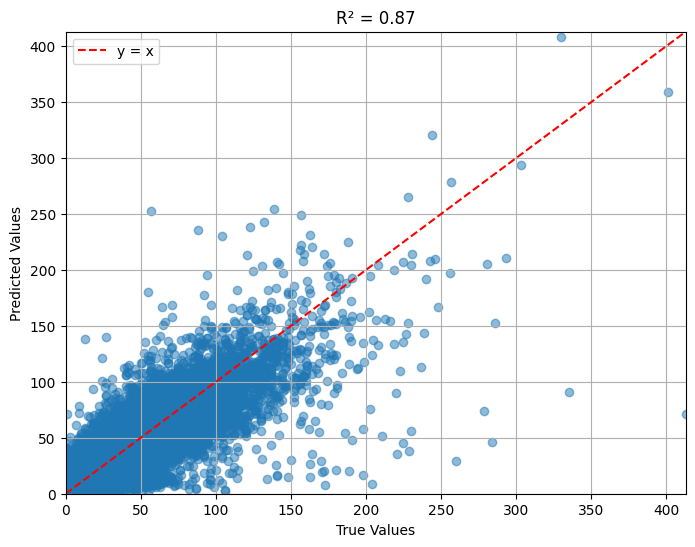

In [74]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(X_p.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, X_p.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = X_p[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


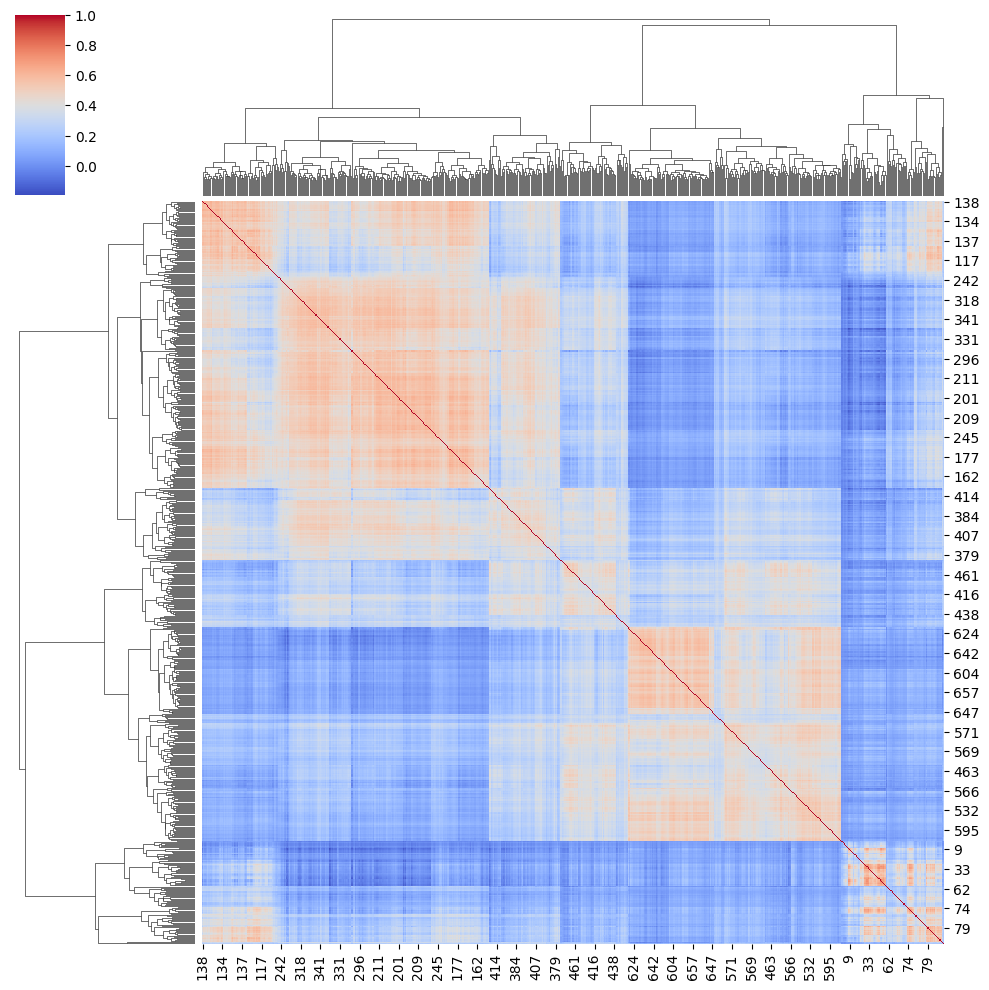

In [ ]:
import torch, pyro
import matplotlib.pyplot as plt
import seaborn as sns                   

with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)
corr = vae._corr(Sigma_P_posterior).numpy()
sns.clustermap(corr, cmap="coolwarm", annot=False)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


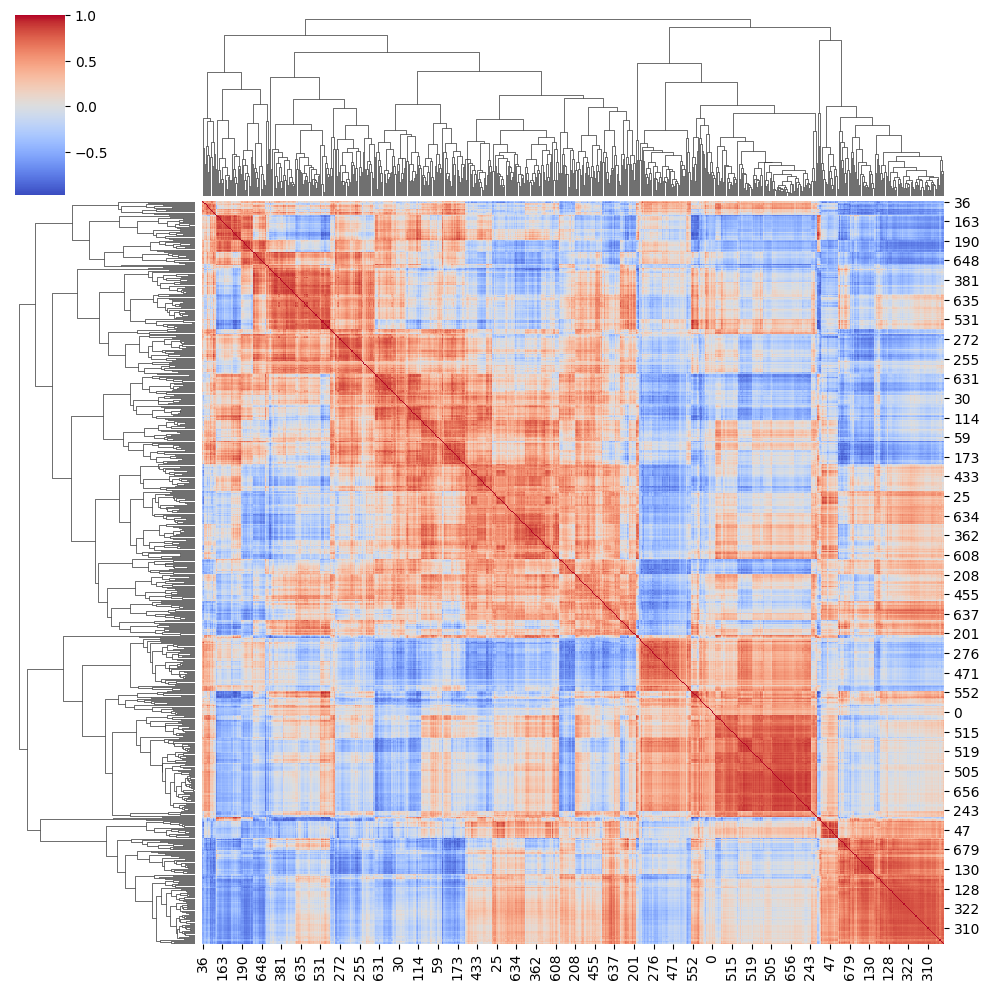

In [ ]:
import torch, pyro
import matplotlib.pyplot as plt
import seaborn as sns                   

with torch.no_grad():
    L = vae.qr().cpu()              
    sigma_P = pyro.param("sigma_fac").cpu()

P_ = L.size(0)
Sigma_P_posterior = L @ L.T + sigma_P**2 * torch.eye(P_)
corr = vae._corr(Sigma_P_posterior).numpy()
sns.clustermap(corr, cmap="coolwarm", annot=False)

In [77]:
np.savetxt("./results/corr_matrix.csv", corr, delimiter=",")
np.savetxt("./results/pi.csv",pi.detach().cpu().numpy(), delimiter=",")

In [78]:
corr_matrix = np.array(pd.read_csv("./results/corr_matrix.csv", header=None))
corr_matrix_2 = np.array(pd.read_csv("./results/corr_matrix_2.csv", header=None))

pi = np.array(pd.read_csv("./results/pi.csv", header=None))
pi_2 = np.array(pd.read_csv("./results/pi_2.csv", header=None))

In [ ]:
from scipy.stats import pearsonr

# Flatten the upper triangular parts of both matrices (excluding the diagonal)
triu_indices = np.triu_indices_from(corr_matrix, k=1)
corr_matrix_flat = corr_matrix[triu_indices]
corr_matrix_2_flat = corr_matrix_2[triu_indices]

# Compute Pearson correlation
pearson_corr, p_value = pearsonr(corr_matrix_flat, corr_matrix_2_flat)
print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {p_value:.3e}")

pearson_corr, p_value = pearsonr(pi.flatten(), pi_2.flatten())
print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {p_value:.3e}")

In [ ]:
# z = trace.nodes["z"]["value"]
# z0 = trace.nodes["z0"]["value"]

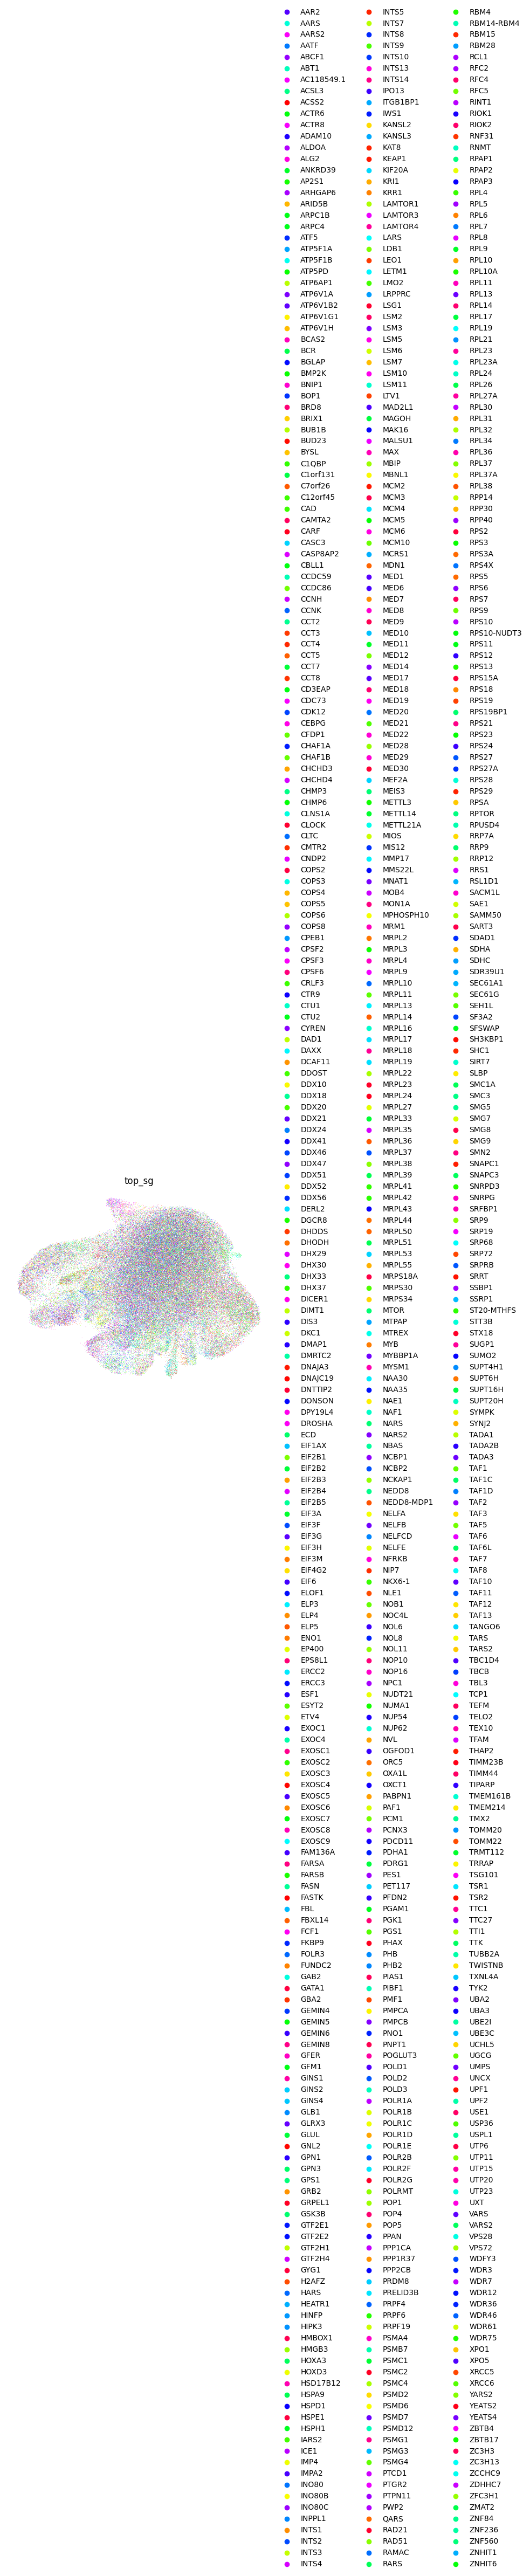

In [ ]:
# z_data = data[data.obs.top_sg != 'NTC'].copy()
# z_data.obsm['z'] = z.detach().cpu().numpy()
# sc.pp.neighbors(z_data, n_neighbors=15, use_rep='X')
# sc.tl.umap(z_data)

import random
n_cats = z_data.obs['top_sg'].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(z_data, color='top_sg', palette=palette, frameon=False)
# sc.pl.umap(z_data, color=['top_sg'], frameon=False, show=True)

In [ ]:
num_p = vae.perturbs
d = vae.latent_dim
Sigma_P_posterior = vae._corr(Sigma_P_posterior)
z_bar = torch.zeros(num_p, d)
counts = torch.zeros(num_p)
for p in range(num_p):
    mask = (P == p)
    if mask.any():
        z_bar[p] = z[mask].mean(0)
        counts[p] = mask.sum()

# (Optional) skip perturbations with very few cells
valid = counts > 2
Sigma_z = torch.corrcoef(z_bar[valid])          # (P_valid × P_valid)
Sigma_P_posterior = Sigma_P_posterior[valid][:, valid]              # align shapes

In [ ]:
def flat_triu(M):
    idx = torch.triu_indices(M.size(0), M.size(1), offset=1)
    return M[idx[0], idx[1]]

rho_flat  = flat_triu(Sigma_P_posterior).numpy()
z_flat    = flat_triu(Sigma_z.detach()).numpy()

from scipy.stats import spearmanr, pearsonr
r_s, p_s = spearmanr(rho_flat, z_flat)
r_p, p_p = pearsonr(rho_flat, z_flat)

print(f"Spearman ρ = {r_s:.3f}  (p = {p_s:.1e})")
print(f" Pearson  r = {r_p:.3f}  (p = {p_p:.1e})")

Spearman ρ = -0.046  (p = 6.3e-107)
 Pearson  r = -0.052  (p = 1.3e-140)


In [ ]:
sigma_w = vae.E_pert_sim(min_conf=0.2).detach().cpu().numpy()

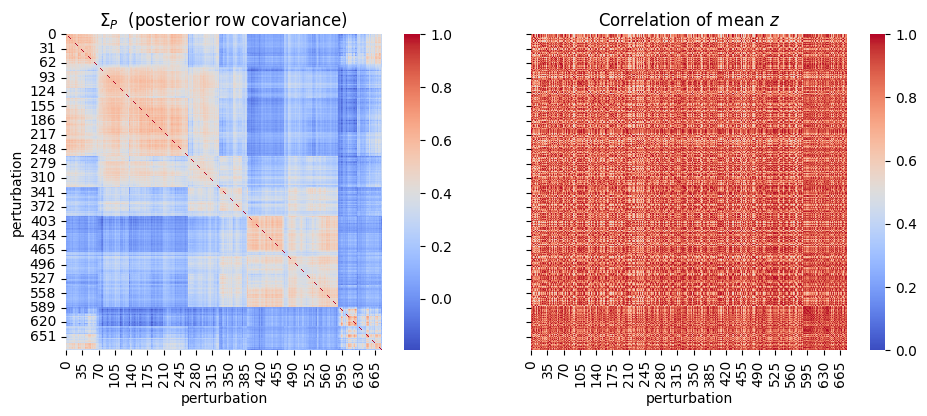

In [ ]:
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import seaborn as sns, matplotlib.pyplot as plt
from matplotlib import gridspec

import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list


link = linkage(Sigma_P_posterior, method="average", metric="euclidean")
order = leaves_list(link)              # permutation indices, shape (P,)

# ── 2.  apply the same permutation to both matrices ─────────────────
SigmaP_ord = Sigma_P_posterior[order][:, order]

# Sigma_z : correlation between perturbation-mean z’s  (P × P)
Sigmaz_ord = Sigma_z.detach().cpu().numpy()[order][:, order]

# Sigma w:
Sigmaw_ord = sigma_w[order][:, order]

# ── 3.  plot side-by-side heat-maps ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=axes[0])
axes[0].set_title(r"$\Sigma_P$  (posterior row covariance)")
axes[0].set_xlabel("perturbation"); axes[0].set_ylabel("perturbation")

sns.heatmap(Sigmaz_ord, cmap="coolwarm", square=True, ax=axes[1], vmin=0)
axes[1].set_title("Correlation of mean $z$")
axes[1].set_xlabel("perturbation")


plt.tight_layout()
plt.show()

In [64]:
n_classes = P.unique().shape[0]
centroids = torch.stack([z[P==k].mean(0) for k in range(n_classes)])
inter = centroids.var(0).sum()
intra = (z - centroids[P]).var(0).sum()
print("inter / intra variance :", inter.item() / intra.item())


inter / intra variance : 1.736986416621998


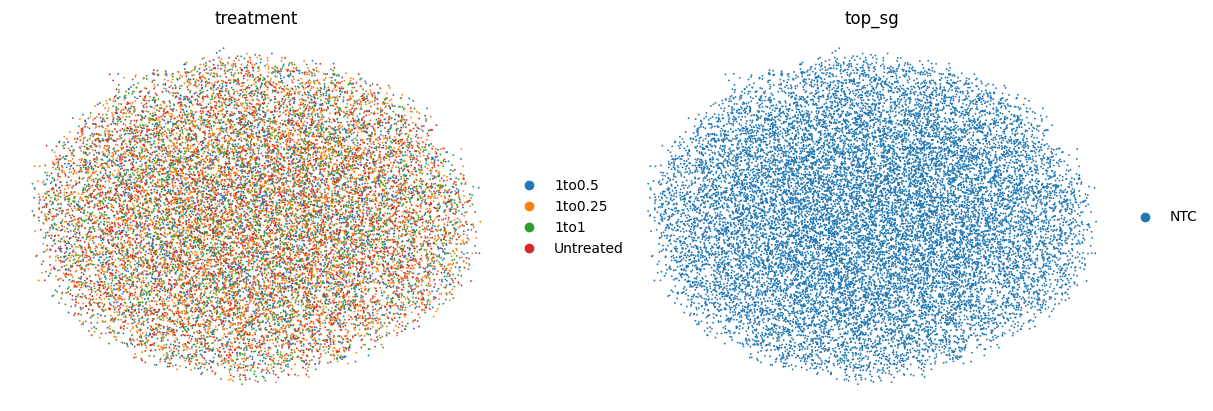

In [30]:
# z0_data = data.copy()
# z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='X', n_neighbors=15)
sc.tl.umap(z0_data)
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [ ]:
pi = trace.nodes["pi"]['value']
pi

tensor([[0.1241, 0.7456, 0.1905, 0.1547, 0.2879, 0.1416],
        [0.1405, 0.0769, 0.1014, 0.0998, 0.0838, 0.6548],
        [0.1226, 0.2946, 0.8801, 0.8027, 0.8267, 0.7104],
        ...,
        [0.4883, 0.7150, 0.4186, 0.7231, 0.6601, 0.5073],
        [0.7426, 0.6987, 0.8372, 0.3993, 0.4909, 0.0792],
        [0.2819, 0.8121, 0.6778, 0.3589, 0.5131, 0.4249]],
       grad_fn=<ExpandBackward0>)

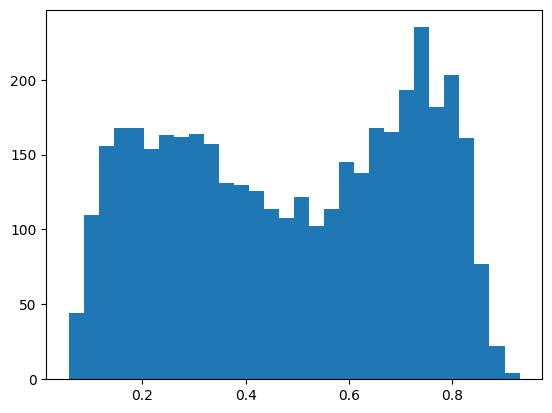

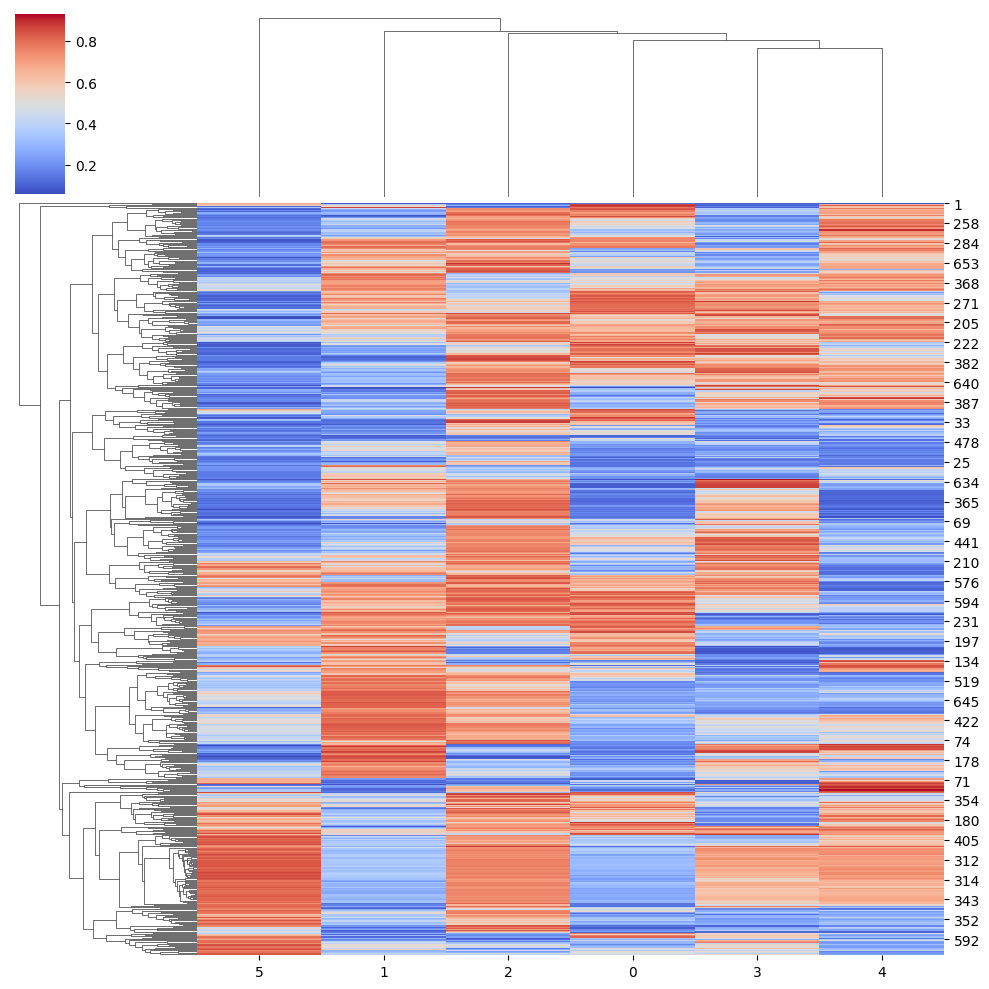

In [ ]:
plt.hist(pi.detach().cpu().numpy().flatten(), bins=30)
plt.show()
sns.clustermap(pi.detach().cpu().numpy(), cmap="coolwarm")

In [33]:
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, metric='euclidean', random_state=0)
Z2 = reducer.fit_transform(z.detach().cpu().numpy())

/opt/conda/envs/perturb/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [34]:
import numpy as np
centroids = np.zeros((vae.perturbs, z.shape[1]))
for a in range(vae.perturbs):
    centroids[a] = z.detach()[P == a].mean(0)
cent2 = reducer.transform(centroids)

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
C = vae._corr(Sigma_P_posterior).cpu().numpy()
D = 1.0 - C  # distance
Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
# groups = fcluster(Z_link, t=0.5, criterion='distance')  # tune t

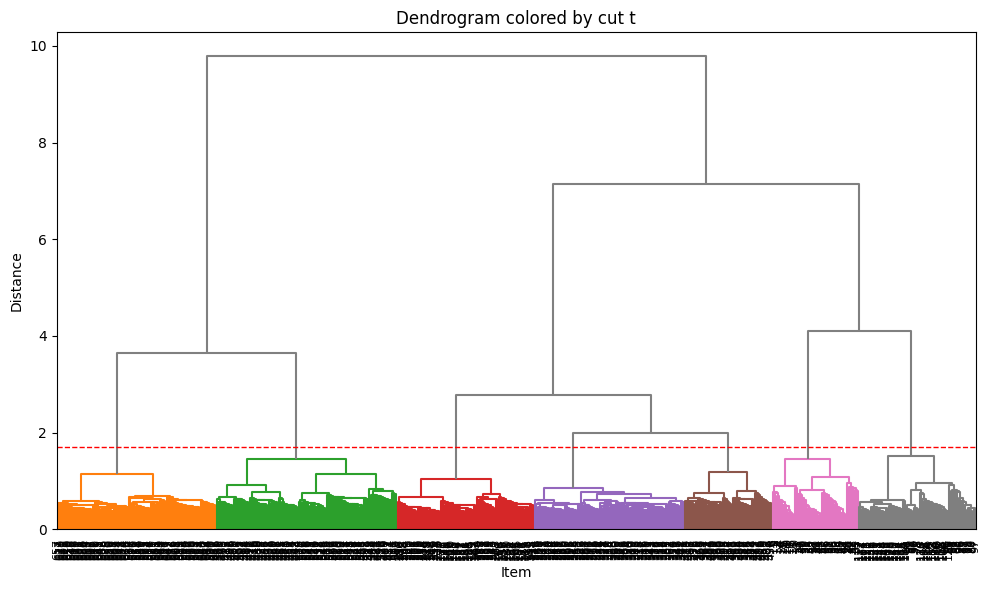

In [ ]:
t = 1.7  # your cut in the same distance scale as Z_link

plt.figure(figsize=(10, 6))
dendrogram(
    Z_link,
    color_threshold=t,            # <-- color branches by your cut
    above_threshold_color="gray", # color for branches above the cut
    labels=np.arange(len(C)),     # optional
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
plt.title("Dendrogram colored by cut t")
plt.xlabel("Item")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Cluster labels at the same cut
groups = fcluster(Z_link, t=t, criterion='distance')

In [ ]:
from collections import Counter

# Flatten all genes from all pathways
all_genes = [gene for genes in data.uns['pathways'].values() for gene in genes]

# Count how many times each gene appears
gene_counts = Counter(all_genes)

# Find genes that appear in more than one pathway
shared_genes = [gene for gene, count in gene_counts.items() if count > 1]

if shared_genes:
    print(f"⚠️ {len(shared_genes)} genes are shared across pathways:")
    print(shared_genes[:20])  # show first 20 for inspection
else:
    print("✅ Each gene appears in exactly one pathway.")


#pert df
pathway_genes = np.concatenate([i for i in list(data.uns['pathways'].values())])
perts = pd.DataFrame(groups, index=dataset.perturbation_dict.keys(), columns=['cluster'])
perts = perts.loc[pathway_genes]

#pathway df
gene_to_pathway = {
    gene: pathway
    for pathway, genes in data.uns['pathways'].items()
    for gene in genes
}
pathway_df = pd.DataFrame.from_dict(gene_to_pathway, orient="index", columns=["cluster"])


perts = perts.drop(shared_genes, errors="ignore")
pathway_df = pathway_df.drop(shared_genes, errors="ignore")

print("After removal:")
print("perts size     :", perts.shape)
print("pathway_df size:", pathway_df.shape)

⚠️ 1 genes are shared across pathways:
['LSM5']
After removal:
perts size     : (335, 1)
pathway_df size: (335, 1)


In [ ]:
from sklearn.metrics import adjusted_rand_score

# Align on the same gene index
perts_aligned = perts.loc[pathway_df.index]

# Compute ARI
ari = adjusted_rand_score(pathway_df["cluster"], perts_aligned["cluster"])
print("ARI =", ari)

ARI = 0.13376251489814753


In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np

y_true = pathway_df["cluster"].values
y_pred = perts_aligned["cluster"].astype(str).values

true_labels = np.unique(y_true)
pred_labels = np.unique(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=true_labels)

# Hungarian algorithm (maximize trace)
row_ind, col_ind = linear_sum_assignment(cm.max() - cm)

# Best mapping cluster → pathway
mapping = {}
for i, j in zip(row_ind, col_ind):
    if i < len(true_labels) and j < len(pred_labels):
        mapping[pred_labels[j]] = true_labels[i]

print("Best cluster-to-pathway mapping:")
for pred, true in mapping.items():
    print(f"  Cluster {pred} → Pathway {true}")

# Remap predictions
y_pred_mapped = np.array([mapping.get(label, "NA") for label in y_pred])
mask = y_pred_mapped != "NA"

# Global alignment accuracy
accuracy = (y_pred_mapped[mask] == y_true[mask]).mean()
print(f"\nGlobal alignment accuracy = {accuracy:.3f}")

# --- Per-cluster accuracy (purity) ---
df_compare = pd.DataFrame({"true": y_true, "pred": y_pred})

cluster_stats = []
for cluster, group in df_compare.groupby("pred"):
    majority_pathway = group["true"].mode()[0]
    purity = (group["true"] == majority_pathway).mean()
    cluster_stats.append({
        "cluster": cluster,
        "mapped_pathway": mapping.get(cluster, "NA"),
        "size": len(group),
        "purity": purity
    })

cluster_df = pd.DataFrame(cluster_stats).set_index("cluster")
print("\nPer-cluster accuracy (purity):")
print(cluster_df)


Best cluster-to-pathway mapping:
  Cluster 1 → Pathway EXOSOME
  Cluster 2 → Pathway MEDIATOR_COMPLEX
  Cluster 3 → Pathway MT_PROTEIN_TRANSLOCATION
  Cluster 4 → Pathway NUCLEOTIDE_EXCISION_REPAIR
  Cluster 5 → Pathway S39_RIBOSOMAL_UNIT
  Cluster 6 → Pathway S40_RIBOSOMAL_UNIT
  Cluster 7 → Pathway S60_RIBOSOMAL_UNIT

Global alignment accuracy = 0.075

Per-cluster accuracy (purity):
                     mapped_pathway  size    purity
cluster                                            
1                           EXOSOME    43  0.372093
2                  MEDIATOR_COMPLEX    85  0.505882
3          MT_PROTEIN_TRANSLOCATION    54  0.166667
4        NUCLEOTIDE_EXCISION_REPAIR    64  0.515625
5                S39_RIBOSOMAL_UNIT    33  0.272727
6                S40_RIBOSOMAL_UNIT    23  0.347826
7                S60_RIBOSOMAL_UNIT    33  0.333333


In [ ]:
# Build DataFrame of per-gene assignments
results_df = pd.DataFrame({
    "gene": pathway_df.index,
    "true_pathway": y_true,
    "pred_cluster": y_pred,
    "mapped_pathway": [mapping.get(c, "NA") for c in y_pred]
})

# Optional: add a correctness flag
results_df["correct"] = results_df["true_pathway"] == results_df["mapped_pathway"]

# Save all genes
results_df.to_csv("./results/gene_cluster_alignment.csv", index=False)

print("✅ Saved per-gene assignments to gene_cluster_alignment.csv")


✅ Saved per-gene assignments to gene_cluster_alignment.csv


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib as mpl


def _discrete_cmap(n, base_cmap='tab20'):
    """
    Make an n-bin discrete ListedColormap from a continuous or qualitative base cmap.
    For large n (e.g., 100), interpolating a continuous cmap (turbo, viridis, gist_ncar)
    actually yields *more* distinct colors than repeating a short qualitative palette.
    """
    base = plt.cm.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, n))
    return ListedColormap(color_list)


def _scanpy_categorical_palette(n, prefer='default', fallback_cmap='gist_ncar'):
    """
    Return a list of n distinct colors using Scanpy's categorical palettes.
    Parameters
    ----------
    n : int
        Number of categories needed.
    prefer : {'default','zeileis','vega','scanpy','any'}
        Preference heuristic; 'default' tries Scanpy's default_* palettes first.
    fallback_cmap : str
        Matplotlib cmap name to fall back to if scanpy unavailable.
    """
    try:
        import scanpy as sc
    except ImportError:
        # fallback: discrete colormap from matplotlib
        return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)

    pals = []
    # Build candidate palettes in preference order
    if prefer in ('default', 'any'):
        pals.extend([
            sc.pl.palettes.default_20,
            getattr(sc.pl.palettes, 'default_28', []),
            sc.pl.palettes.default_102,   # length 102
        ])
    if prefer in ('zeileis', 'any'):
        # Zeileis palettes are good for many categories
        pals.extend([
            sc.pl.palettes.zeileis_26,
            sc.pl.palettes.zeileis_102,   # length 102
        ])
    if prefer in ('vega', 'scanpy', 'any'):
        # Additional widely used palettes
        pals.extend([
            sc.pl.palettes.vega_20_scanpy,
            sc.pl.palettes.vega_20,       # original vega
        ])

    # deduplicate while preserving order
    seen = set()
    uniq_pals = []
    for pal in pals:
        if pal is None:
            continue
        # convert to tuple so hashable
        tpl = tuple(pal)
        if tpl in seen:
            continue
        seen.add(tpl)
        uniq_pals.append(list(pal))

    # choose the *smallest* palette that still covers n
    chosen = None
    for pal in uniq_pals:
        if len(pal) >= n:
            chosen = pal[:n]
            break

    if chosen is None:
        # no palette long enough; take the longest and extend by cycling
        longest = max(uniq_pals, key=len) if uniq_pals else []
        if not longest:  # still empty? fallback
            return list(_discrete_cmap(n, base_cmap=fallback_cmap).colors)
        reps = int(np.ceil(n / len(longest)))
        chosen = (longest * reps)[:n]

    return chosen


def plot_umap_cells_by_cluster_and_pert(
    Z2, P, cent2, groups,
    *,
    cluster_base_cmap=None,
    pert_base_cmap='gist_ncar',
    use_scanpy_palette_for_pert=True,
    use_scanpy_palette_for_groups=False,
    scanpy_palette_prefer='default',
    cell_size=5,
    alpha_cells=0.6,
    centroid_size=80,
    annotate_centroids=False,
    max_cluster_legend=25,
    fig_kw=None,
):
    Z2 = np.asarray(Z2)
    P = np.asarray(P, dtype=int)
    cent2 = np.asarray(cent2)
    groups = np.asarray(groups)

    n_cells = Z2.shape[0]
    n_pert = cent2.shape[0] if cent2 is not None else P.max() + 1

    # ---- cluster mapping ----
    grp_labels, grp_codes = np.unique(groups, return_inverse=True)  # grp_codes: (n_pert,)
    G = len(grp_labels)
    cell_grp = grp_codes[P]  # cluster id per cell

    # choose cluster cmap
    if use_scanpy_palette_for_groups:
        cluster_colors = _scanpy_categorical_palette(G, prefer=scanpy_palette_prefer)
        cluster_cmap = ListedColormap(cluster_colors)
    else:
        if cluster_base_cmap is None:
            if G <= 10:
                cluster_base_cmap = 'tab10'
            elif G <= 20:
                cluster_base_cmap = 'tab20'
            else:
                cluster_base_cmap = 'hsv'
        cluster_cmap = _discrete_cmap(G, base_cmap=cluster_base_cmap)
        cluster_colors = cluster_cmap(np.arange(G))

    # per-perturbation cmap
    if use_scanpy_palette_for_pert:
        pert_colors = _scanpy_categorical_palette(n_pert, prefer=scanpy_palette_prefer,
                                                  fallback_cmap=pert_base_cmap)
        pert_cmap = ListedColormap(pert_colors)
    else:
        pert_cmap = _discrete_cmap(n_pert, base_cmap=pert_base_cmap)

    # ---- figure ----
    if fig_kw is None:
        fig_kw = {}
    fig, axes = plt.subplots(
        1, 2,
        figsize=fig_kw.get('figsize', (12, 5)),
        sharex=True, sharey=True,
        gridspec_kw=fig_kw.get('gridspec_kw', None),
        constrained_layout=fig_kw.get('constrained_layout', False)
    )

    axc, axp = axes

    # ------------------------------------------------------------------
    # Panel 1: Cells colored by cluster
    # ------------------------------------------------------------------
    axc.scatter(
        Z2[:, 0], Z2[:, 1],
        c=cell_grp,
        cmap=cluster_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    axc.set_title("z space, Cells colored by perturbation groups", fontsize=10)

    # Legend (clusters)
    if G <= max_cluster_legend:
        if use_scanpy_palette_for_groups:
            cluster_colors_arr = np.array(cluster_colors)
        else:
            cluster_colors_arr = cluster_cmap(np.arange(G))
        handles = [
            mpatches.Patch(color=cluster_colors_arr[i], label=f"group {grp_labels[i]}")
            for i in range(G)
        ]
        axc.legend(
            handles=handles,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=8,
            title='Perturbation groups'
        )

    # ------------------------------------------------------------------
    # Panel 2: Cells colored by individual perturbation (Scanpy colors)
    # ------------------------------------------------------------------
    axp.scatter(
        Z2[:, 0], Z2[:, 1],
        c=P,
        cmap=pert_cmap,
        s=cell_size,
        alpha=alpha_cells,
        linewidths=0
    )
    if annotate_centroids:
        for a, (x_, y_) in enumerate(cent2):
            axp.text(x_, y_, str(a), ha='center', va='center', fontsize=4, zorder=4)

    axp.set_title("z space, Cells colored by perturbation", fontsize=10)

    # Colorbar for perturbations (compact; index scale 0..n_pert-1)
    stride = max(1, n_pert // 20)  # show at most ~20 ticks
    ticks = np.arange(0, n_pert, stride)
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=n_pert-1), cmap=pert_cmap),
        ax=axp,
        fraction=0.046,
        pad=0.04,
    )
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticks.astype(str))
    cbar.set_label("Perturbation ID")

    # ------------------------------------------------------------------
    # Finishing touches
    # ------------------------------------------------------------------
    for ax in axes:
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    return fig, axes


/var/tmp/ipykernel_1584257/2393065932.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap(base_cmap)


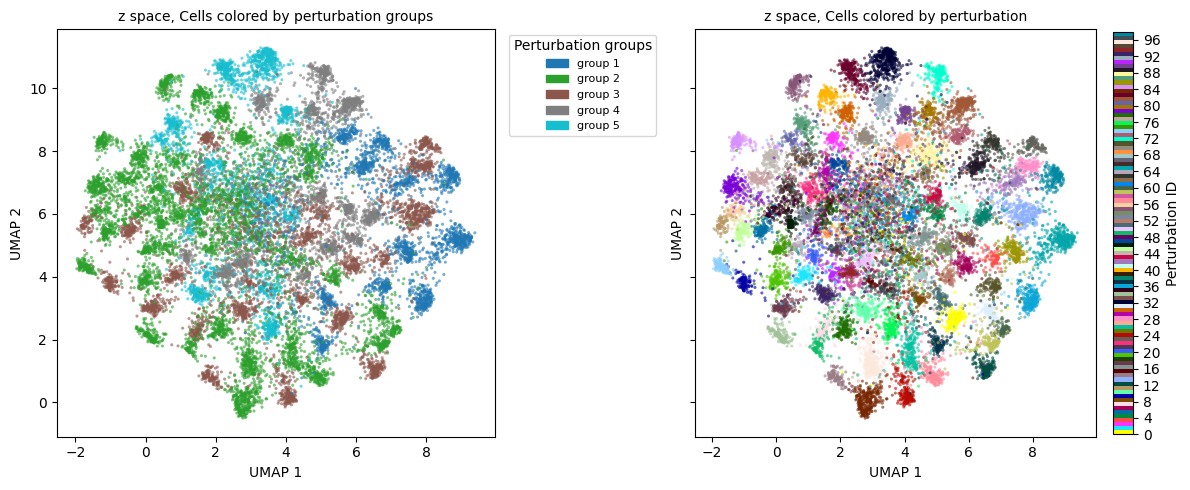

In [38]:
fig, axes = plot_umap_cells_by_cluster_and_pert(
    Z2=Z2,
    P=P,
    cent2=cent2,
    groups=groups,
    pert_base_cmap='nipy_spectral',   # high-contrast for many categories
    annotate_centroids=False,     # set True to label perturbations at centroids
)
plt.show()

In [ ]:
tau_init=2.0

vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=data.var['module'].values, tau=tau_init,
                 center_coeff_init=1, use_gene_modules=True)
vae = vae.to(vae.device)

trainer = VAETrainer(
    vae,
    dataloader,
    lr=1e-3,
    num_epochs=300,
    init_coeff=vae.center_coeff_init,                 
    final_coeff=1e-1,                 
    ramp_steps=10000, 
    tau_init=tau_init,
    tau_end=0.2,
    tau_anneal_steps=10000,
    #tau_anneal_steps=20000,  
    gate_start=2,

# Check W consistency

In [11]:
def _initialize_vaes(dataset, tau_init=2.0, n_models=5):
    vaes = []
    for _ in range(n_models):
        # Initialize a new VAE for each model
        input_dim = data.shape[-1] 
        vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 perturb_dim, module_var=data.var['module'].values, tau=tau_init,
                 center_coeff_init=1, use_gene_modules=True)
        vae = vae.to(vae.device)
        vaes.append(vae)
    return vaes

In [12]:
models = _initialize_vaes(dataset, n_models=5)
param_stores = []

In [13]:
import tqdm

In [14]:
for i in tqdm.tqdm(range(len(models))):
    trainer = VAETrainer(
        models[i],
        dataloader,
        lr=1e-3,
        num_epochs=300,
        init_coeff=models[i].center_coeff_init,                 
        final_coeff=1e-1,                 
        ramp_steps=10000, 
        tau_init=models[i].tau_init,
        tau_end=0.2,
        tau_anneal_steps=10000,
        #tau_anneal_steps=20000,  
        gate_start=2,
        seed=i + 42,
        verbose=False
    )
    best_model, best_param_store = trainer.fit()
    models[i] = best_model
    param_stores.append(best_param_store)

  0%|          | 0/5 [00:00<?, ?it/s]

Training VAE on cuda …


Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 297:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 298:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 299:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 300:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [49:26<00:00, 593.22s/it]


In [15]:
from utils import *

In [ ]:
def _model_trace(model, dataset):
    model.eval()
    model.device = torch.device('cpu')
    model = model.to(model.device)
    print(model.device)

    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):       
        param_store[name] = value.to(torch.device('cpu'))            

    X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
    X_ntc = []
    for i in C:
        rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
        X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
    X_ntc = torch.stack(X_ntc, dim=0)
                        
    trace = poutine.trace(model.guide).get_trace(X_p, X_ntc, P, C)
    trace_model = poutine.trace(poutine.replay(model.model, trace=trace)).get_trace(X_p, X_ntc, P, C)


    return trace, trace_model

In [29]:
Ws, Pis = [], []             # graph-level statistics
Zs, Z0s, Rhos, corrs = [], [], [], []    # optional latent diagnostics

for run_idx, vae in enumerate(tqdm.tqdm(models, desc="collect posteriors")):

    # --------  move model + params to CPU and eval mode  ----------
    vae.eval()
    vae.to("cpu")
    vae.device = torch.device('cpu')
    pyro.get_param_store().set_state(param_stores[run_idx])         

    # print(torch.mean(q_pi))
    # print(torch.max(q_pi))

    # --------  draw one trace if you want latent snapshots  -------
    param_store = pyro.get_param_store()
    for name, value in list(param_store.items()):       
        param_store[name] = value.to(torch.device('cpu'))            

    X_p, P, C = torch.tensor(dataset.X_pert, dtype=torch.float32), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)
    X_ntc = []
    for i in C:
        rand_idx = np.random.randint(0, len(dataset.X_ntc[i]), size=1)[0]
        X_ntc.append(torch.tensor(dataset.X_ntc[i][rand_idx], dtype=torch.float32))
    X_ntc = torch.stack(X_ntc, dim=0)
                        
    trace = poutine.trace(vae.guide).get_trace(X_p, X_ntc, P, C)
    trace_model = poutine.trace(poutine.replay(vae.model, trace=trace)).get_trace(X_p, X_ntc, P, C)

    Zs.append(trace.nodes["z"]["value"].detach().cpu())
    Z0s.append(trace.nodes["z0"]["value"].detach().cpu())
    Rhos.append(trace.nodes["rho"]["value"].detach().cpu())
    q_pi = trace.nodes["pi"]["value"].detach().cpu()
    Pis.append(q_pi)
    S_map = q_pi >= 0.5
    Ws.append(S_map)

    rho_cov = vae._get_cov()
    rho_corr = vae._corr(rho_cov).detach().cpu().numpy()
    corrs.append(rho_corr)


collect posteriors:   0%|          | 0/5 [00:00<?, ?it/s]

collect posteriors: 100%|██████████| 5/5 [00:04<00:00,  1.10it/s]


In [30]:
def upper_tri_vec(M):
    iu = np.triu_indices_from(M, k=1)
    return M[iu]

In [32]:
from scipy.stats import pearsonr
n = len(corrs)
pairwise_P = np.eye(n, dtype=float)

for (i, j) in itertools.combinations(range(n), 2):
    v1 = upper_tri_vec(corrs[i])
    v2 = upper_tri_vec(corrs[j])
    r, p = pearsonr(v1, v2)
    pairwise_P[i, j] = r
    pairwise_P[j, i] = r

# ---- summary stats ----
tri_i, tri_j = np.triu_indices(n, k=1)
vals = pairwise_P[tri_i, tri_j]
print("\n=== Consistency cov ===")
print(f"Mean r: {vals.mean():.4f} | Median r: {np.median(vals):.4f} | Min r: {vals.min():.4f} | Max r: {vals.max():.4f}")


=== Consistency cov ===
Mean r: 0.5954 | Median r: 0.5659 | Min r: 0.4399 | Max r: 0.7678


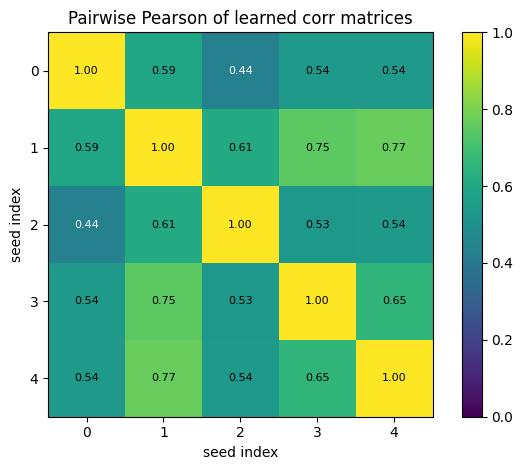

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(pairwise_P, vmin=0, vmax=1)


n = pairwise_P.shape[0]
for i in range(n):
    for j in range(n):
        v = pairwise_P[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color=("white" if v < 0.5 else "black"), fontsize=8)

# (optional) label ticks with actual seed values if you have `seeds = [0,1,2,3,4]`
try:
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
except NameError:
    pass  # falls back to index labels

ax.set_title("Pairwise Pearson of learned corr matrices")
ax.set_xlabel("seed index")
ax.set_ylabel("seed index")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.gridspec import GridSpec

def plot_corrs_with_shared_order(corr_list, labels=None, method="average"):
    assert len(corr_list) >= 1, "Provide at least one correlation matrix."
    G = corr_list[0].shape[0]
    assert all(C.shape == (G, G) for C in corr_list), "All matrices must be the same size and square."

    # cluster on first matrix
    C0 = corr_list[0]
    D0 = 1.0 - C0
    np.fill_diagonal(D0, 0.0)
    Z = linkage(squareform(D0, checks=False), method=method)
    order = leaves_list(Z)

    ordered_corrs = [C[np.ix_(order, order)] for C in corr_list]
    if labels is not None:
        labels = [labels[i] for i in order]

    n = len(ordered_corrs)
    fig = plt.figure(figsize=(3.2*n + 2.5, 3.2 + 1.6))
    gs = GridSpec(2, n, height_ratios=[1, 8], hspace=0.08, wspace=0.15, figure=fig)

    # dendrogram above first heatmap
    ax_dend = fig.add_subplot(gs[0, 0])
    dendrogram(Z, no_labels=True, color_threshold=None)
    ax_dend.set_xticks([]); ax_dend.set_yticks([])
    for spine in ax_dend.spines.values():
        spine.set_visible(False)

    # heatmaps
    vmin, vmax = 0.3, 1.0
    ims, heat_axes = [], []
    for j, C in enumerate(ordered_corrs):
        ax = fig.add_subplot(gs[1, j])
        im = ax.imshow(C, vmin=vmin, vmax=vmax, aspect="auto", interpolation="nearest", cmap='coolwarm')
        ims.append(im)
        heat_axes.append(ax)
        ax.set_title(f"Matrix {j+1}", fontsize=10, pad=6)

        if labels is not None and G <= 60:
            ax.set_xticks(np.arange(G)); ax.set_yticks(np.arange(G))
            ax.set_xticklabels(labels, fontsize=7, rotation=90)
            ax.set_yticklabels(labels, fontsize=7)
        else:
            ax.set_xticks([]); ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

    # shared colorbar without creating a new subplot that covers the last panel
    cbar = fig.colorbar(ims[-1], ax=heat_axes, fraction=0.046, pad=0.04)
    cbar.set_label("correlation", fontsize=9)

    plt.tight_layout()
    plt.show()

/var/tmp/ipykernel_671094/4111610708.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


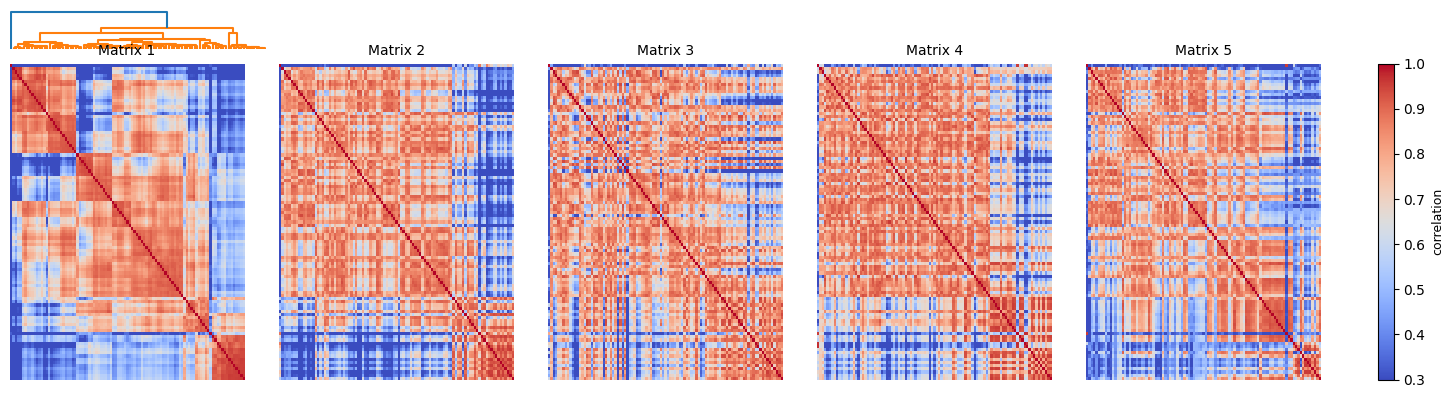

In [35]:
plot_corrs_with_shared_order(corrs, labels=None, method="average")

In [98]:
from utils import *

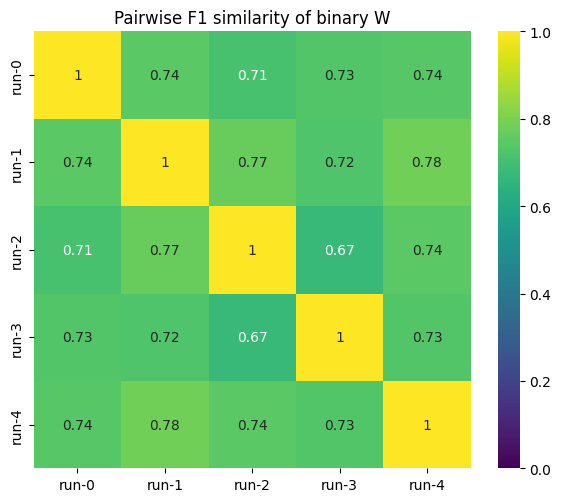

Mean f1 = 0.734 ± 0.029


In [28]:
compare_W_runs_binary(Ws, align=False)